In [3]:
import os
import sys
sys.path.append('/home/royhirsch/conformal/')

from ml_collections import config_dict
import logging
import pandas as pd
import pickle
import torch
import torch.nn as nn

from conformal_baselines import calc_baseline_mets
from model import NN
from trainer import Trainer, get_optimizer, get_scheduler
from config import get_config_by_name
import utils as utils
import matplotlib.pyplot as plt
import numpy as np

from data_v2 import get_dataloaders
from train_v2 import train

## Init exp

In [4]:
config = get_config_by_name('tissuemnist')
config.conformal_module_name = 'aps'
config.num_epochs = 60
config.use_score_clipping = False 
config.device = torch.device('cuda:1')
config.alpha = 0.1

utils.seed_everything(config.seed)

In [5]:
above_dls, below_dls = get_dataloaders(config)

Num samples above: 14608 Num samples below: 32672 (threshold is 0.9)
##### Above subset #####
train shape: (12363,)
valid shape: (1076,)
test shape: (1169,)


  4%|▍         | 4/100 [00:00<00:22,  4.23it/s]


Temp is 1.2612
Globel qhat: 0.9968
##### Below subset #####
train shape: (27653,)
valid shape: (2405,)
test shape: (2614,)


  2%|▏         | 2/100 [00:01<01:03,  1.55it/s]

Temp is 1.1996
Globel qhat: 0.9552


## Train NNs

### Above model

In [6]:
config.conformal_module_name = 'aps'
config.num_epochs = 80
config.lr = 1e-4
config.criteria_name = 'nll'
config.hidden_dim = [128,32]
config.out_dim = 2

above_model, above_history, above_outs = train(above_dls, config, input_key='probs')

NN(
  (layers): Sequential(
    (0): Linear(in_features=8, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=2, bias=True)
  )
)


  5%|▌         | 4/80 [00:01<00:34,  2.20it/s]/home/royhirsch/miniconda3/envs/conf/lib/python3.11/site-packages/torch/optim/lr_scheduler.py:152: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)
[L2] train: 0.0005 | val: 0.0005 || [R2] train: 0.834 | val: 0.819: 100%|██████████| 80/80 [00:32<00:00,  2.47it/s]


### Below model

In [7]:
config.conformal_module_name = 'aps'
config.num_epochs = 100
config.lr = 5e-4
config.criteria_name = 'nll'
config.hidden_dim = [128,32]
config.out_dim = 2

below_model, below_history, below_outs = train(below_dls, config, input_key='probs')

NN(
  (layers): Sequential(
    (0): Linear(in_features=8, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=2, bias=True)
  )
)


  4%|▍         | 4/100 [00:03<01:26,  1.11it/s]/home/royhirsch/miniconda3/envs/conf/lib/python3.11/site-packages/torch/optim/lr_scheduler.py:152: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)
[L2] train: 0.0272 | val: 0.0277 || [R2] train: 0.178 | val: 0.178: 100%|██████████| 100/100 [01:30<00:00,  1.10it/s]


Group num 1|| edges: [0.00136,0.00908], count: 601, R^2=0.211 
Group num 2|| edges: [0.00908,0.01679], count: 326, R^2=0.073 
Group num 3|| edges: [0.01679,0.02451], count: 283, R^2=0.089 
Group num 4|| edges: [0.02451,0.03223], count: 275, R^2=0.027 
Group num 5|| edges: [0.03223,0.03994], count: 302, R^2=0.046 
Group num 6|| edges: [0.03994,0.04766], count: 292, R^2=0.024 
Group num 7|| edges: [0.04766,0.05538], count: 170, R^2=0.026 
Group num 8|| edges: [0.05538,0.06309], count: 107, R^2=0.010 
Group num 9|| edges: [0.06309,0.07081], count: 36, R^2=-0.056 
Group num 10|| edges: [0.07081,0.07853], count: 13, R^2=-0.017 


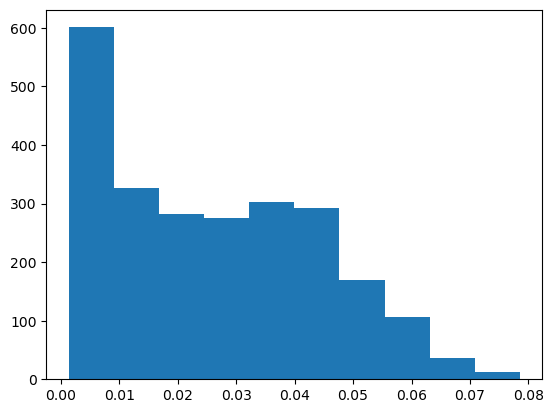

In [11]:
from sklearn.metrics import r2_score
outs = below_outs
split = 'valid'

pred_sigma = outs[split]['pred_scores'][:,1]
pred_sigma = np.clip(np.exp(pred_sigma), a_min=1e-4, a_max=1e10)
counts, edges, _ = plt.hist(pred_sigma, bins=10)


group2preds = {i: [] for i in range(len(edges))}
for pred, gt_score in zip(outs[split]['pred_scores'], outs[split]['true_scores']):
    pred_mean = pred[0]
    pred_sigma = np.clip(np.exp(pred[1]), a_min=1e-4, a_max=1e10)
    group2preds[np.digitize(pred_sigma, edges[:-1])].append((pred_mean, gt_score))


edges = edges.round(5)
for k, v in group2preds.items():
    if len(v):
        r2 = r2_score([i[1] for i in v], [i[0] for i in v])
        print(f'Group num {k}|| edges: [{edges[k-1]},{edges[k]}], count: {len(v)}, R^2={r2:.3f} ')


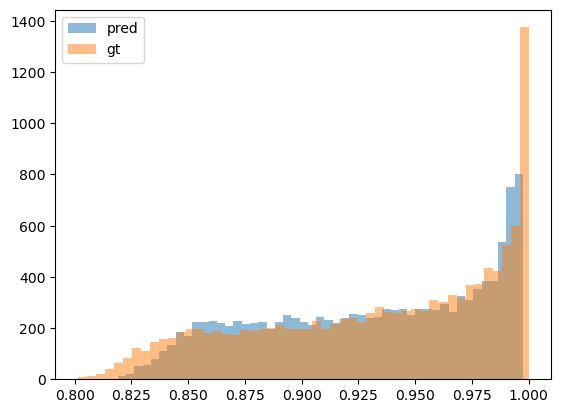

In [9]:
outs = above_outs
_ = plt.hist(outs['train']['pred_scores'][:,0],bins=50,label='pred',alpha=0.5)
_ = plt.hist(outs['train']['true_scores'],bins=50,label='gt',alpha=0.5)
plt.legend()